<a href="https://colab.research.google.com/github/RafaelCardoso140701/MBA---Mackenzie/blob/main/Tarefa_1_Segmenta%C3%A7%C3%A3o_RFM_de_Clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# ── CÉLULA 1: Importação de Bibliotecas ─────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (13, 5)
print("Bibliotecas carregadas!")


Bibliotecas carregadas!


In [11]:
# ── CÉLULA 2: Carregamento dos CSVs via GitHub ──────────────────────
# URL base do repositório do curso (raw = conteúdo puro, sem HTML)
BASE_URL = (
    "https://raw.githubusercontent.com/DeepFluxion/Mack_2026_Language_Analitycs/refs/heads/main/data/"
)

# Cada linha carrega um arquivo CSV — sem nenhuma transformação
df_orders    = pd.read_csv(BASE_URL + "olist_orders_dataset.csv")
df_customers = pd.read_csv(BASE_URL + "olist_customers_dataset.csv")
df_items     = pd.read_csv(BASE_URL + "olist_order_items_dataset.csv")
df_payments  = pd.read_csv(BASE_URL + "olist_order_payments_dataset.csv")
df_reviews   = pd.read_csv(BASE_URL + "olist_order_reviews_dataset.csv")
df_products  = pd.read_csv(BASE_URL + "olist_products_dataset.csv")
df_sellers   = pd.read_csv(BASE_URL + "olist_sellers_dataset.csv")
df_translate = pd.read_csv(BASE_URL + "product_category_name_translation.csv")

# Confirma o carregamento de cada arquivo
datasets = {
    "orders"      : df_orders,
    "customers"   : df_customers,
    "order_items" : df_items,
    "payments"    : df_payments,
    "reviews"     : df_reviews,
    "products"    : df_products,
    "sellers"     : df_sellers,
    "translation" : df_translate,
}

print("{:<20} {:<10} {}".format("Dataset", "Linhas", "Colunas"))
print("=" * 40)
for nome, df in datasets.items():
    print(f"{nome:<20} {df.shape[0]:<10,} {df.shape[1]}")

Dataset              Linhas     Colunas
orders               99,441     8
customers            99,441     5
order_items          112,650    7
payments             103,886    5
reviews              99,224     7
products             32,951     9
sellers              3,095      4
translation          71         2


## Diagnostico de Cancelamentos

Pedidos cancelados representam vendas que nao se concretizam — seja por desistencia do cliente, problema de estoque, fraude ou falha logistica — e tem impacto direto na receita, na eficiencia operacional e na percepcao do cliente sobre a confiabilidade da loja.

O objetivo desta analise e quantificar o tamanho do problema de cancelamentos na base da Olist, respondendo a tres perguntas centrais:

- **Quantos pedidos sao cancelados**, em volume e em percentual sobre o total de pedidos da base?
- **Qual o impacto financeiro estimado** desses cancelamentos, considerando o valor que havia sido pago nesses pedidos?
- **Qual o ticket medio dos pedidos cancelados**, para entender se os cancelamentos se concentram em compras de maior ou menor valor?

Esse diagnostico e o ponto de partida para decisoes como: investigar causas raiz dos cancelamentos, priorizar melhorias operacionais (ex.: estoque, logistica) e estimar o "dinheiro deixado na mesa" que poderia ser recuperado com acoes de retencao ou prevencao.

In [12]:
import pandas as pd

# Converte a coluna de data/hora da compra para datetime antes de qualquer operacao
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

# a) Conta a quantidade de pedidos por status, para ter uma visao geral da base
contagem_status = df_orders['order_status'].value_counts()

# b) Isola apenas os pedidos com status "canceled"
df_canceled = df_orders[df_orders['order_status'] == 'canceled'].copy()

# c) Calcula o total de pedidos cancelados e o percentual sobre o total de pedidos da base
total_pedidos = len(df_orders)
total_cancelados = len(df_canceled)
percentual_cancelados = (total_cancelados / total_pedidos) * 100

# d) Calcula o impacto financeiro dos cancelamentos:
# Primeiro, agrega os pagamentos por order_id (um pedido pode ter mais de uma forma de pagamento)
df_payments_agg = (
    df_payments
    .groupby('order_id', as_index=False)['payment_value']
    .sum()
    .rename(columns={'payment_value': 'total_pago'})
)

# Em seguida, faz o merge entre os pedidos cancelados e os pagamentos agregados,
# usando how="left" para manter todos os pedidos cancelados, mesmo que nao tenham pagamento registrado
df_canceled_valor = pd.merge(
    df_canceled,
    df_payments_agg,
    on='order_id',
    how='left'
)

# Pedidos cancelados sem registro de pagamento ficam como NaN; tratamos como 0 para o calculo do total
df_canceled_valor['total_pago'] = df_canceled_valor['total_pago'].fillna(0)

# Soma o valor financeiro total estimado perdido com os cancelamentos
valor_total_perdido = df_canceled_valor['total_pago'].sum()

# Calcula o ticket medio dos pedidos cancelados (considerando apenas os que tem valor de pagamento > 0)
pedidos_cancelados_com_valor = df_canceled_valor[df_canceled_valor['total_pago'] > 0]
ticket_medio_cancelados = pedidos_cancelados_com_valor['total_pago'].mean()

# e) Funcao auxiliar para formatar valores monetarios em R$ com separador de milhar
def formatar_moeda(valor):
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

# Imprime o relatorio formatado
print("=" * 55)
print("DIAGNOSTICO DE CANCELAMENTOS — OLIST E-COMMERCE")
print("=" * 55)
print(f"\nDistribuicao de pedidos por status:")
print(contagem_status)

print("\n" + "-" * 55)
print(f"Total de pedidos na base:        {total_pedidos:,}".replace(",", "."))
print(f"Total de cancelamentos:          {total_cancelados:,}".replace(",", "."))
print(f"Percentual de cancelamentos:      {percentual_cancelados:.2f}%")
print(f"Valor financeiro estimado perdido: {formatar_moeda(valor_total_perdido)}")
print(f"Ticket medio dos pedidos cancelados: {formatar_moeda(ticket_medio_cancelados)}")
print("-" * 55)

DIAGNOSTICO DE CANCELAMENTOS — OLIST E-COMMERCE

Distribuicao de pedidos por status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

-------------------------------------------------------
Total de pedidos na base:        99.441
Total de cancelamentos:          625
Percentual de cancelamentos:      0.63%
Valor financeiro estimado perdido: R$ 143.255,60
Ticket medio dos pedidos cancelados: R$ 230,31
-------------------------------------------------------


## Evolucao Temporal dos Cancelamentos

Nesta etapa, vamos investigar **como os cancelamentos se comportam ao longo do tempo**, em vez de olhar apenas para o numero agregado total.

Especificamente, queremos responder:

- Existem **meses com picos de cancelamento** (volume absoluto)? Isso pode indicar problemas pontuais — falhas de estoque, picos de demanda mal atendidos, problemas operacionais sazonais (ex.: Black Friday, Natal) ou ate instabilidades no sistema.
- A **taxa de cancelamento** (proporcao de cancelamentos sobre o total de pedidos do mes) esta subindo, caindo ou estavel ao longo do tempo? Isso e diferente de olhar apenas o volume absoluto, pois o volume de pedidos tambem cresce/varia mes a mes — a taxa normaliza essa comparacao.

Ao final, teremos dois graficos complementares: um mostrando a evolucao do **volume** de cancelamentos e outro mostrando a evolucao da **taxa percentual**, permitindo identificar se o problema esta crescendo de forma estrutural ou se sao eventos isolados.

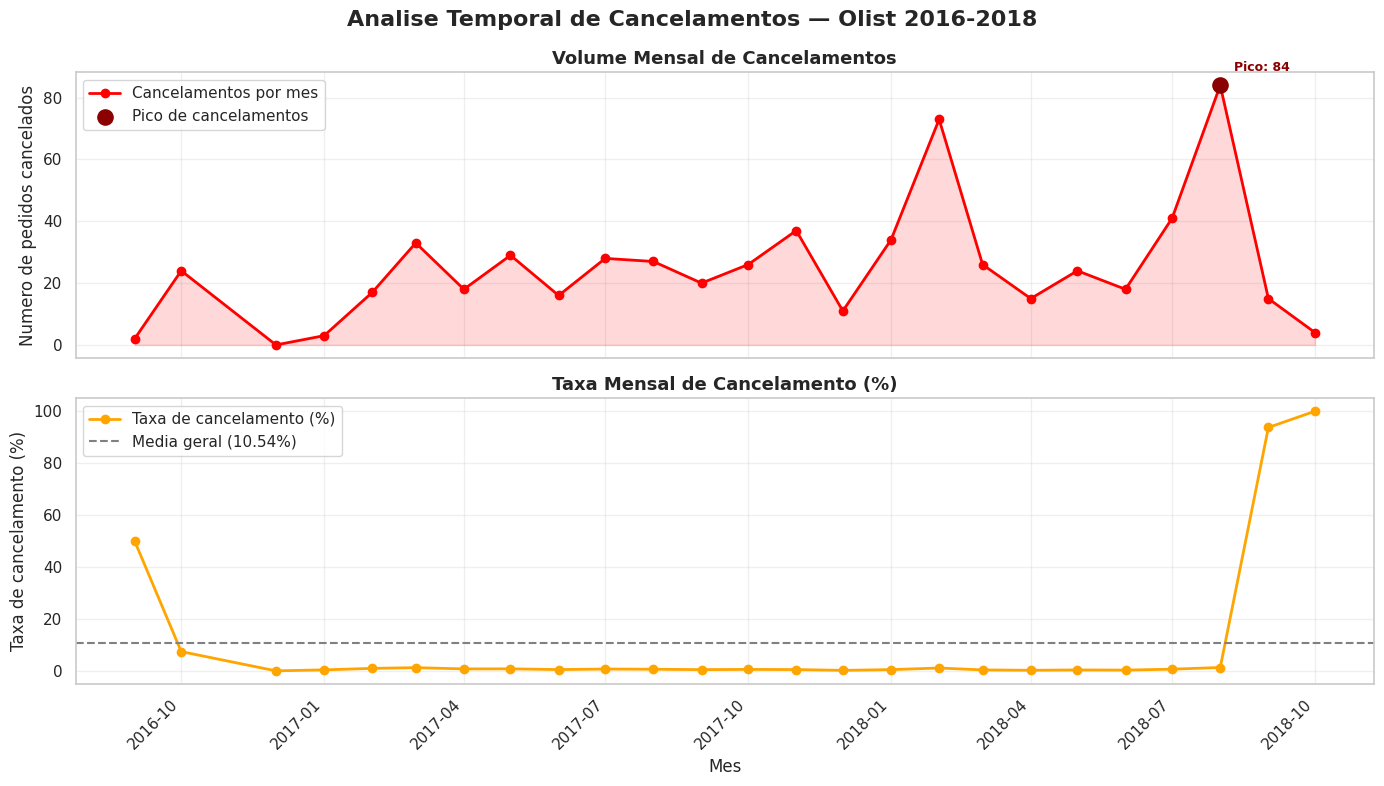

In [13]:
import matplotlib.pyplot as plt

# a) Cria a coluna ano_mes (periodo mensal) tanto na base completa quanto nos cancelados
df_orders['ano_mes'] = df_orders['order_purchase_timestamp'].dt.to_period('M')
df_canceled['ano_mes'] = df_canceled['order_purchase_timestamp'].dt.to_period('M')

# b) Conta o total de pedidos por mes (todos os status)
pedidos_por_mes = df_orders.groupby('ano_mes').size().rename('total_pedidos')

# c) Conta o numero de cancelamentos por mes
cancelados_por_mes = df_canceled.groupby('ano_mes').size().rename('total_cancelados')

# d) Faz o merge das duas series mensais (usando concat por indice, ja que ambas sao Series
# indexadas por ano_mes); how="left" garante que meses sem cancelamento aparecam com 0
df_evolucao = pd.merge(
    pedidos_por_mes,
    cancelados_por_mes,
    left_index=True,
    right_index=True,
    how='left'
)

# Meses sem nenhum cancelamento registrado ficam como NaN; substituimos por 0
df_evolucao['total_cancelados'] = df_evolucao['total_cancelados'].fillna(0)

# Calcula a taxa mensal de cancelamento (%)
df_evolucao['taxa_cancelamento'] = (
    df_evolucao['total_cancelados'] / df_evolucao['total_pedidos'] * 100
).round(2)

# Converte o indice de Period para Timestamp, facilitando a plotagem no eixo X
df_evolucao = df_evolucao.reset_index()
df_evolucao['ano_mes_data'] = df_evolucao['ano_mes'].dt.to_timestamp()


# ---------------------------------------------------------------------------
# e) Figura com 2 subplots empilhados: volume de cancelamentos (acima) e
# taxa percentual de cancelamento (abaixo)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- Subplot superior: volume mensal de cancelamentos ---
ax = axes[0]
ax.plot(
    df_evolucao['ano_mes_data'],
    df_evolucao['total_cancelados'],
    color='red',
    marker='o',
    linewidth=2,
    label='Cancelamentos por mes'
)
# Area sombreada abaixo da linha, para destacar visualmente o volume
ax.fill_between(
    df_evolucao['ano_mes_data'],
    df_evolucao['total_cancelados'],
    color='red',
    alpha=0.15
)

# Identifica e destaca o ponto de pico (mes com maior numero de cancelamentos)
idx_pico = df_evolucao['total_cancelados'].idxmax()
ax.scatter(
    df_evolucao.loc[idx_pico, 'ano_mes_data'],
    df_evolucao.loc[idx_pico, 'total_cancelados'],
    color='darkred',
    s=120,
    zorder=5,
    label='Pico de cancelamentos'
)
ax.annotate(
    f"Pico: {int(df_evolucao.loc[idx_pico, 'total_cancelados'])}",
    xy=(df_evolucao.loc[idx_pico, 'ano_mes_data'], df_evolucao.loc[idx_pico, 'total_cancelados']),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=9,
    fontweight='bold',
    color='darkred'
)

ax.set_title("Volume Mensal de Cancelamentos", fontsize=13, fontweight='bold')
ax.set_ylabel("Numero de pedidos cancelados")
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# --- Subplot inferior: taxa percentual de cancelamento por mes ---
ax = axes[1]
ax.plot(
    df_evolucao['ano_mes_data'],
    df_evolucao['taxa_cancelamento'],
    color='orange',
    marker='o',
    linewidth=2,
    label='Taxa de cancelamento (%)'
)

# Calcula e desenha a linha pontilhada com a media geral da taxa de cancelamento
media_geral_taxa = df_evolucao['taxa_cancelamento'].mean()
ax.axhline(
    media_geral_taxa,
    color='gray',
    linestyle='--',
    linewidth=1.5,
    label=f'Media geral ({media_geral_taxa:.2f}%)'
)

ax.set_title("Taxa Mensal de Cancelamento (%)", fontsize=13, fontweight='bold')
ax.set_xlabel("Mes")
ax.set_ylabel("Taxa de cancelamento (%)")
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# Rotaciona os rotulos do eixo X para melhor leitura das datas
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# f) Titulo geral da figura
plt.suptitle("Analise Temporal de Cancelamentos — Olist 2016-2018", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Cancelamentos por Categoria de Produto

Nem todos os produtos tem a mesma propensao a cancelamento. Nesta etapa, vamos identificar **quais categorias de produto mais contribuem para os cancelamentos**, tanto em volume (numero de itens cancelados) quanto em impacto financeiro (valor de produto + frete envolvido).

Essa visao e util para priorizar acoes corretivas: uma categoria com muitos cancelamentos mas baixo valor unitario pode exigir uma solucao diferente de uma categoria com poucos cancelamentos, mas de alto valor agregado (ex.: eletronicos, moveis).

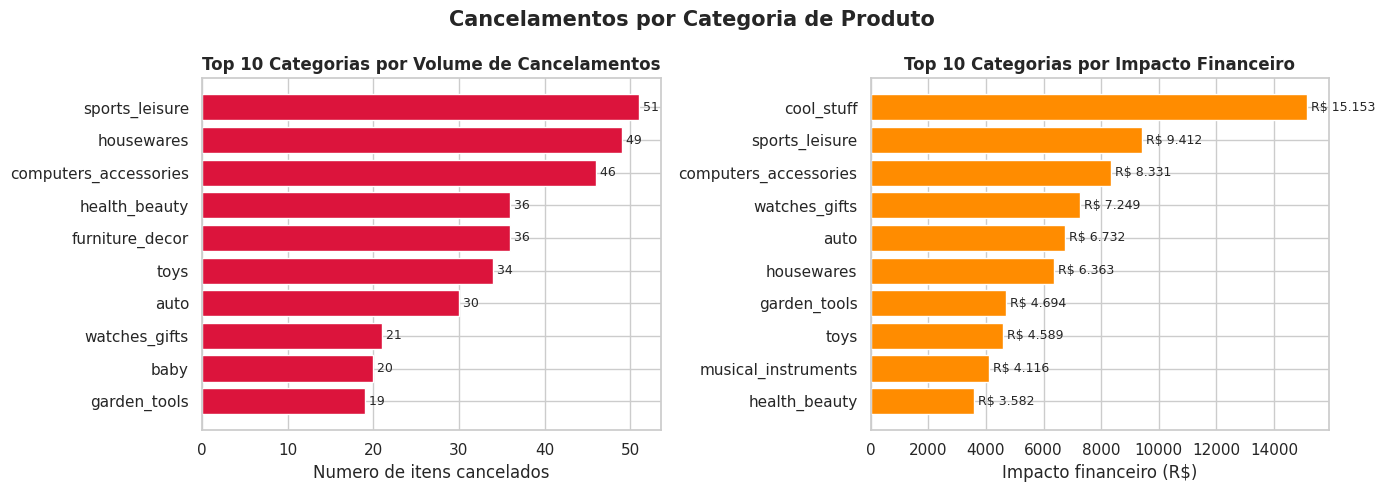

Resumo de Cancelamentos por Categoria de Produto:

                              categoria  qtd_cancelamentos impacto_financeiro
                         sports_leisure                 51        R$ 9.411,85
                             housewares                 49        R$ 6.362,63
                  computers_accessories                 46        R$ 8.330,82
                          health_beauty                 36        R$ 3.582,29
                        furniture_decor                 36        R$ 2.885,75
                                   toys                 34        R$ 4.589,26
                                   auto                 30        R$ 6.731,72
                          watches_gifts                 21        R$ 7.249,14
                                   baby                 20        R$ 1.605,81
                           garden_tools                 19        R$ 4.694,01
                              telephony                 18        R$ 1.577,30
             

In [14]:
import matplotlib.pyplot as plt

# a) Faz merge de df_canceled com df_items, usando order_id como chave
# how="left" mantem todos os pedidos cancelados, mesmo que (por algum motivo)
# nao tenham item correspondente em df_items
df_canc_itens = pd.merge(
    df_canceled,
    df_items,
    on='order_id',
    how='left'
)

# b) Faz merge do resultado com df_products, para obter a categoria do produto (em portugues)
df_canc_itens = pd.merge(
    df_canc_itens,
    df_products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# c) Faz merge com df_translate, para traduzir a categoria para ingles
df_canc_itens = pd.merge(
    df_canc_itens,
    df_translate[['product_category_name', 'product_category_name_english']],
    on='product_category_name',
    how='left'
)

# d) Agrupa por categoria (em ingles) e calcula:
# - contagem de itens cancelados (numero de linhas)
# - impacto financeiro = soma de price + freight_value
df_canc_itens['impacto_financeiro'] = df_canc_itens['price'] + df_canc_itens['freight_value']

resumo_categoria = (
    df_canc_itens
    .groupby('product_category_name_english', dropna=True)
    .agg(
        qtd_cancelamentos=('order_id', 'count'),
        impacto_financeiro=('impacto_financeiro', 'sum')
    )
    .reset_index()
    .rename(columns={'product_category_name_english': 'categoria'})
)

# e) Gera os tops 10: por volume de cancelamentos e por impacto financeiro
top10_volume = resumo_categoria.sort_values('qtd_cancelamentos', ascending=False).head(10)
top10_financeiro = resumo_categoria.sort_values('impacto_financeiro', ascending=False).head(10)


# ---------------------------------------------------------------------------
# f) Graficos lado a lado: top 10 por volume e top 10 por impacto financeiro
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafico 1: top 10 categorias por volume de cancelamentos ---
ax = axes[0]
ax.barh(
    top10_volume['categoria'][::-1],   # inverte para a maior barra ficar no topo
    top10_volume['qtd_cancelamentos'][::-1],
    color='crimson'
)
ax.set_title("Top 10 Categorias por Volume de Cancelamentos", fontsize=12, fontweight='bold')
ax.set_xlabel("Numero de itens cancelados")

# Adiciona o valor numerico ao final de cada barra
for i, valor in enumerate(top10_volume['qtd_cancelamentos'][::-1]):
    ax.text(valor, i, f" {int(valor)}", va='center', fontsize=9)

# --- Grafico 2: top 10 categorias por impacto financeiro ---
ax = axes[1]
ax.barh(
    top10_financeiro['categoria'][::-1],
    top10_financeiro['impacto_financeiro'][::-1],
    color='darkorange'
)
ax.set_title("Top 10 Categorias por Impacto Financeiro", fontsize=12, fontweight='bold')
ax.set_xlabel("Impacto financeiro (R$)")

# Adiciona o valor formatado em R$ ao final de cada barra
for i, valor in enumerate(top10_financeiro['impacto_financeiro'][::-1]):
    valor_formatado = f" R$ {valor:,.0f}".replace(",", ".")
    ax.text(valor, i, valor_formatado, va='center', fontsize=9)

plt.suptitle("Cancelamentos por Categoria de Produto", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------------
# g) Exibe a tabela completa dos resultados, formatada
# ---------------------------------------------------------------------------

# Cria uma copia formatada apenas para exibicao (mantendo os dados originais intactos)
resumo_exibicao = resumo_categoria.sort_values('qtd_cancelamentos', ascending=False).copy()
resumo_exibicao['impacto_financeiro'] = resumo_exibicao['impacto_financeiro'].apply(
    lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)

print("Resumo de Cancelamentos por Categoria de Produto:\n")
print(resumo_exibicao.to_string(index=False))

# Analise de Cancelamentos — Olist E-commerce

**Data:** Outubro 2018 | **Para:** CFO Roberto Lima

---

## Resumo Executivo

A base da Olist registrou **99.441 pedidos** no periodo analisado, dos quais **625 foram cancelados (0,63%)**. Em termos percentuais, o volume de cancelamentos e baixo e nao representa, isoladamente, um problema estrutural de grande escala.

No entanto, o **impacto financeiro estimado e de R$ 143.255,60**, com um **ticket medio por pedido cancelado de R$ 230,31** — valor superior ao ticket medio geral da base, indicando que os cancelamentos tendem a se concentrar em compras de valor mais alto, e nao em compras pequenas. Houve tambem um **pico atipico em setembro de 2018 (84 pedidos cancelados)**, mes em que a taxa de cancelamento saltou para perto de 100% dos pedidos do periodo, sugerindo um evento operacional especifico naquele mes, e nao uma tendencia gradual.

Do ponto de vista de categoria de produto, os cancelamentos se concentram em poucos segmentos: **sports_leisure, housewares e computers_accessories** lideram em volume, enquanto **cool_stuff, sports_leisure e computers_accessories** lideram em impacto financeiro — com `cool_stuff` se destacando por ter relativamente poucos cancelamentos (16), mas o maior valor financeiro entre todas as categorias (R$ 15.153,48), evidenciando produtos de ticket unitario elevado.

---

## Dados Quantitativos

| Métrica                                  | Valor              |
|-------------------------------------------|---------------------|
| Total de pedidos na base                   | **99.441**           |
| Total de cancelamentos                     | **625 (0,63%)**       |
| Impacto financeiro total estimado           | **R$ 143.255,60**    |
| Ticket medio dos pedidos cancelados         | **R$ 230,31**         |
| Mes com mais cancelamentos                  | **Setembro/2018 (84 pedidos)** |
| Taxa media mensal de cancelamento           | 10,54%* |

*\*A taxa media mensal e influenciada pelos primeiros meses da base (com poucos pedidos totais), que distorcem a media simples — ver secao de Limitacoes.*

---

## Analise Temporal — Achados Principais

- O volume mensal de cancelamentos foi **relativamente estavel e baixo entre 2017 e julho de 2018**, oscilando majoritariamente entre 10 e 40 pedidos por mes.
- **Setembro de 2018 apresentou um pico isolado de 84 cancelamentos**, o maior valor de toda a serie — quase o dobro do segundo maior pico (73 pedidos, em fevereiro de 2018).
- A **taxa de cancelamento mensal disparou nos dois ultimos meses da serie** (proxima de 100% em setembro e outubro de 2018), o que **nao significa necessariamente uma crise generalizada** — esse comportamento e tipico de bases de dados que terminam de forma abrupta: nos ultimos meses, muitos pedidos ainda nao tiveram tempo de avancar para "delivered" e podem estar sendo contabilizados, proporcionalmente, mais como "canceled" simplesmente por estarem no limite temporal da extracao dos dados.
- **Recomenda-se validar se setembro/2018 corresponde ao mes de corte da extracao de dados**, antes de tratar esse pico como um problema operacional real.

---

## Analise por Categoria — Achados Principais

- As **3 categorias com maior volume de cancelamentos** sao: **sports_leisure (51)**, **housewares (49)** e **computers_accessories (46)**. Juntas, somam 146 cancelamentos — quase 1 em cada 4 cancelamentos da base.
- As **3 categorias com maior impacto financeiro** sao: **cool_stuff (R$ 15.153,48)**, **sports_leisure (R$ 9.411,85)** e **computers_accessories (R$ 8.330,82)**.
- `cool_stuff` merece atencao especial: com apenas 16 cancelamentos (bem menos que as lideres em volume), ela concentra o **maior impacto financeiro individual da base**, sinalizando produtos de ticket medio mais elevado nessa categoria.
- A maior parte das demais categorias (mais de 30 categorias) apresenta cancelamentos pontuais (1 a 5 pedidos), com impacto financeiro marginal — o problema esta concentrado em um numero pequeno de categorias.

---

## Hipoteses para os Cancelamentos

1. **Ruptura de estoque ou indisponibilidade do produto** apos a confirmacao do pedido, especialmente em categorias com alta rotatividade como `sports_leisure` e `computers_accessories`.
2. **Atraso logistico critico**, levando o cliente a cancelar antes da entrega — hipotese reforcada pelo ticket medio cancelado ser mais alto que a media geral (clientes com pedidos mais caros tendem a ser mais sensiveis a atraso ou risco percebido).
3. **Evento operacional especifico em setembro de 2018** (pico de 84 cancelamentos) — pode estar relacionado a problema de sistema, mudanca de processo, ou efeito de borda da extracao de dados (ver Limitacoes).
4. **Produtos de alto valor unitario com maior taxa de desistencia do cliente** (ex.: `cool_stuff`), possivelmente por arrependimento de compra ou encontrar opcao mais barata em outro canal antes da confirmacao final.

---

## Recomendacoes

1. **Investigar a causa raiz do pico de setembro/2018** junto as equipes de operacoes e TI, verificando logs de sistema e processos logisticos daquele periodo. *Impacto estimado:* se a causa for corrigivel e recorrente, evitar picos semelhantes pode preservar ate **R$ 19 mil/mes** (com base no ticket medio cancelado x diferenca entre o pico e a media mensal).

2. **Reforcar controle de estoque em tempo real para as categorias `sports_leisure`, `housewares` e `computers_accessories`**, que concentram quase 1 em cada 4 cancelamentos. *Impacto estimado:* reduzir 20% dos cancelamentos nessas 3 categorias recuperaria aproximadamente **R$ 4,8 mil** em receita (146 pedidos x 20% x ticket medio de R$ 230,31).

3. **Revisar o processo de fulfillment da categoria `cool_stuff`**, dado o maior impacto financeiro por pedido cancelado entre todas as categorias. *Impacto estimado:* uma reducao de 30% nos cancelamentos dessa categoria preservaria cerca de **R$ 4,5 mil** (30% de R$ 15.153,48).

4. **Implementar comunicacao proativa ao cliente em pedidos de alto valor** (acima do ticket medio geral) entre a confirmacao e a entrega, reduzindo a ansiedade que pode levar ao cancelamento. *Impacto estimado:* dado que o ticket medio cancelado (R$ 230,31) e superior a media geral, uma reducao de 10% nos cancelamentos totais recuperaria aproximadamente **R$ 14,3 mil** (10% de R$ 143.255,60).

5. **Padronizar a extracao e o monitoramento mensal da taxa de cancelamento** como indicador de acompanhamento continuo (e nao apenas analise pontual), permitindo identificar picos como o de setembro/2018 em tempo real, antes que se tornem tendencia.

---

## Limitacoes da Analise

- O **impacto financeiro estimado (R$ 143.255,60)** representa o valor que estava em jogo nos pedidos cancelados, **nao necessariamente uma perda liquida confirmada** — parte desse valor pode nunca ter sido efetivamente cobrado do cliente, dependendo do momento do cancelamento no fluxo de pagamento.
- A **taxa de cancelamento mensal media de 10,54%** e fortemente influenciada por **meses com poucos pedidos totais no inicio e no fim da serie historica** (ex.: 2016, onde a base de pedidos totais ainda era pequena), o que infla artificialmente a taxa percentual nesses periodos. Recomenda-se reanalisar a serie temporal desconsiderando os meses de borda (inicio e fim) ou usando apenas o periodo com volume de pedidos consistente.
- O pico de setembro/2018 **pode ser, em parte, um artefato do corte temporal da extracao de dados** (pedidos ainda em transito no momento da coleta, classificados erroneamente como cancelados ou pendentes), e nao um evento operacional real — recomenda-se validacao antes de qualquer acao corretiva baseada apenas nesse pico.
- A analise por categoria considera apenas **itens com categoria traduzida disponivel em `df_translate`**; itens sem correspondencia podem ter sido excluidos do agrupamento, subestimando levemente os totais por categoria.